Для аугментаций в этом уроке вы будете использовать библиотеку `albumentations`. В ней есть несколько основных параметров и классов, которые наследуются во все аугментации и позволяют объединять их в один конвейер. По аналогии с torchvision, все аугментации объединяются методом `Compose`, каждая из аугментаций в котором обладает параметром вероятности применения, `p=[0, 1.0]`. Поскольку все аугментации выбираются случайно, для воспроизводимости или дебаггинга можно указать параметр `seed` в `Compose` или же использовать задание глобальной переменной `PYTHONHASHSEED`.

Чтобы применить аугментации к изображению, нужно проинициализировать их и передать на вход изображение. В результате получится словарь, в котором трансформированное изображение можно найти по ключу `image`. 
Так сделано потому, что помимо самих изображений некоторые аугментации можно применять к разметке изображений. Например, квадрат, выделяющий на картинке котика, можно растянуть или сжать, как и само изображение.

In [1]:
import albumentations as A
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

c:\Users\aseva\Desktop\MyEDU\YaDLE\YaDLE_gensim_vscode_stream_4\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SIZE = 224


# функция визуализирует исходное и аугментированное изображение
def plot_image(original, transformed, figsize=(5, 2.5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # оригинал
    ax1.imshow(original, cmap='gray')
    ax1.set_title('original')
    ax1.axis('off')

    # аугментации
    ax2.imshow(transformed, cmap='gray')
    ax2.set_title('transformed')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()


# загружаем и сохраняем картинку
#url = "https://raw.githubusercontent.com/jigsawpieces/dog-api-images/main/corgi/14917192_10154550690893449_81787730512372227_o.jpg"
#response = requests.get(url, stream=True)

#with open("data/corgi.jpg", "wb") as f:
#     f.write(response.content)

img = Image.open("../data/corgi.jpg") 
img = np.array(img)

# 1. Масштабирование и обрезка
Здесь есть такие варианты:
* `Resize` — базовое масштабирование.
* `SmallestMaxSize`, `LongestMaxSize` — масштабируют изображения так, что наименьшая или наибольшая сторона приводится к задаваемому значению.
* `RandomCrop` — выделение случайного прямоугольника на изображении с обрезкой всего, не попавшего в периметр. Применяется после масштабирования.
* `RandomResizedCrop` — то же, что RandomCrop, но уже объединённое с масштабированием.

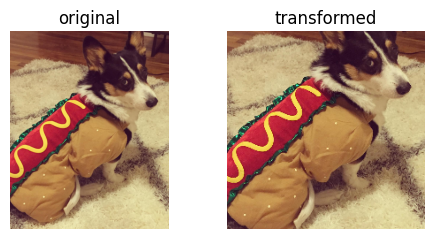

In [3]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0)
    ],
    seed=42,
)

plot_image(img, transforms(image=img)["image"]) 

# 2. Геометрические
* `HorizontalFlip` — отражение по горизонтали.
* `SquareSymmetry` — поворот на 0-270 градусов с шагом 90 градусов.

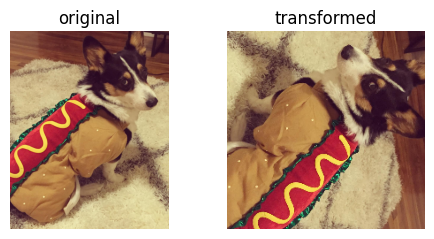

In [5]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1) # не принимает других аргументов на вход
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"]) 

# 3. Перспектива и аффинные преобразования
* `Perspective` — приближение объекта.
* `Affine` — изменяют объект так, что все параллельные линии на изображении остаются параллельными после трансформации.

Аргументы задаются диапазоном значений (min, max):
* `scale` — кратность отдаления или приближения объекта соответственно.
* `rotate` — поворот в градусах.
* `translate_percent` — смещение всего изображения вдоль одной из осей, в примере мы допускаем смещение на 1/10 часть изображения.
* `shear` — трапециевидный сдвиг, угол смещения, который превращает прямоугольное изображение в трапецию. В примере от –10° до +10°.
* `fill` — целое число, цветовое значение пикселя для заполнения образовавшейся пустоты, используется по аналогии и в других аугментациях. 0 — чёрный, 255 — белый цвет.

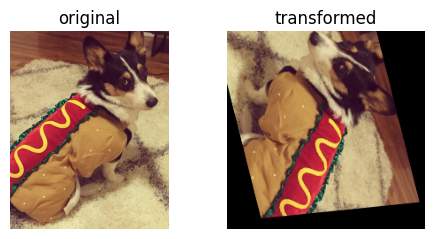

In [6]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(
                scale=(0.8, 1.2), rotate=(-15, 15), fill=0,
                translate_percent=(-0.1, 0.1), shear=(-10, 10), p=1
            ),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"]) 

# 4. Dropout
* `CoarseDropout` — удаление случайных прямоугольных областей.
* `GridDropout` — удаление случайных прямоугольных областей, расположенных по равномерной сетке.

Аргументы (min, max):
* `num_holes_range` — число удаляемых областей, задаётся диапазоном.
* `hole_height_range`, `hole_width_range` — высота и ширина удаляемых областей, в примере задан как доля от размера картинки.

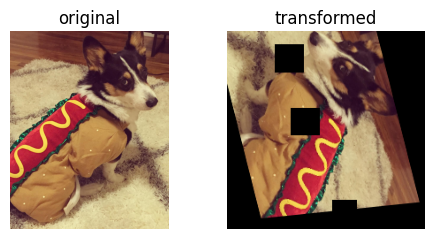

In [7]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
    ],
    seed=4,
)


plot_image(img, transforms(image=img)["image"]) 

# 5. Изменяющие цветовые каналы
* `ToGray` — перевод в чёрно-белое изображение.
* `ChannelDropout` — удаление цветового канала (из RGB) и заполнение фиксированным оттенком (fill).

где:
* `channel_drop_range` — число случайно удаляемых каналов от 1 до 2 максимум. 
* `fill` и `p` несут тот же смысл, что и в прошлых аугментациях.

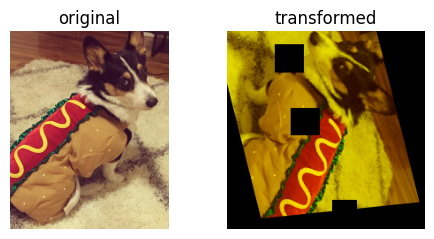

In [8]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"]) 

# 6. Изменения цвета
* `RandomBrightnessContrast` — изменения яркости и контрастности.
* `HueSaturationValue` — изменение насыщенности и оттенков цветов.
* `ColorJitter` — одновременное изменение яркости, контрастности, насыщенности и оттенков цветов.

Аргументы принимают либо диапазон изменения значений (0.8, 1.2), либо дробное число (0.2 эквивалентно (0.8, 1.2); 0 = без изменений):
* `brightness` — яркость,
* `contrast` — контраст,
* `saturation` — насыщенность,
* `hue` — оттенок.

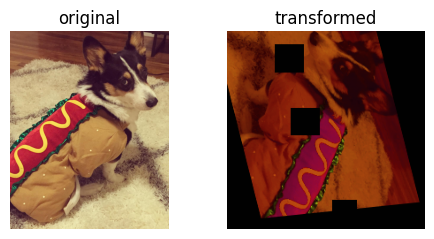

In [9]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
        A.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"]) 

# 7. Размытия
Позволяют убрать шумы на изображении.
* `GaussianBlur` — размытие с гауссовым фильтром.
* `MotionBlur` — имитация размытия от движения.

где:
* `blur_limit` — размер применяемого фильтра в пикселях. Больше — сильнее размытие.

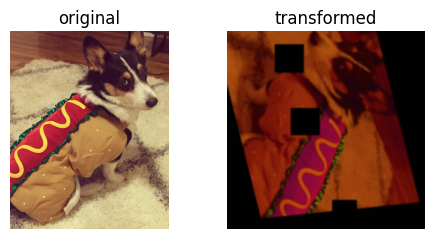

In [10]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
        A.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
        A.GaussianBlur(blur_limit=(3, 10), p=0.5),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"]) 

# 8. Шумы
Случайные изменения значений пикселей.
* `GaussNoise` — добавление шума из нормального распределения.
* `ISONoise` — изменения оттенков.
* `SaltAndPepper` — случайно заменяет значения пикселей на максимальное (Salt, или белые пиксели) или минимальное (Pepper, или черные пиксели) значение, вычисленные по самому изображению.

где:
* `amount` — диапазон доли случайно изменяемых пикселей.

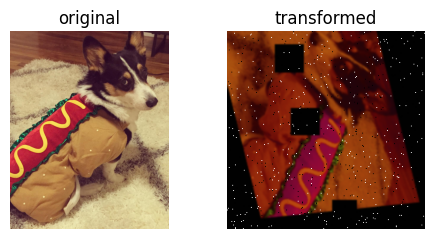

In [11]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
        A.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
        A.GaussianBlur(blur_limit=(3, 10), p=0.5),
        A.SaltAndPepper(amount=(0.01, 0.06), p=0.5),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"]) 

# 9. Артефактные
Ухудшают качество изображения.
* `ImageCompression` — применяют алгоритмы сжатия jpeg и webp для ухудшения качества.
* `Downscale` — уменьшает, а затем восстанавливает разрешение изображения до исходного размера. За счёт этого качество теряется.

где:
* `scale_range` — относительный диапазон для применения сжатия.

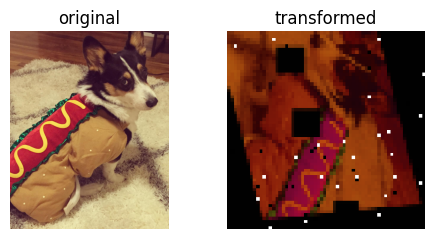

In [12]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
        A.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
        A.GaussianBlur(blur_limit=(3, 10), p=0.5),
        A.SaltAndPepper(amount=(0.01, 0.06), p=0.5),
        A.Downscale(scale_range=(0.25, 0.5), p=0.5),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"]) 

# 10. Нормализация
Как и `torchvision.Normalize`, `albumentations` имеет свою аугментацию для нормализации — `Norimalize`. В этой аугментации есть стандартные параметры `mean`, `std`, позволяющие нормализовать изображение на средние характеристики всего датасета. Но возможны также другие виды нормализации, задаваемые через параметр `normalization`: 
* standard — вышеописанные подходы через указание mean, std.
* image — каждая картинка будет нормализовываться на свои средние значения mean, std по всем каналам.
* image_per_channel — то же самое, что и image, но поканально.

Последние два подхода могут служить дополнительной регуляризацией модели.

**NB!:** Порядок аугментаций важен — старайтесь его придерживаться, чтобы избежать нежелательных артефактов. Например, применив сначала шумы, а потом аффинное преобразование, можно изменить размер артефактов шумов и получить сильно искажённое изображение. *Нормализация всегда применяется последней*.

# Задание 1
Используйте комбинацию аугментаций с произвольными параметрами Affine, Resize, MotionBlur на изображении img и визуализируйте его (визуализация уже есть в прекоде). 
* Выберите правильный порядок для аугментации. 
* Установите вероятность равной 1, seed=42. 
* Целевой масштаб указан в параметре SIZE.
* Порядок применения: Resize → Affine → MotionBlur.

c:\Users\aseva\Desktop\MyEDU\YaDLE\YaDLE_gensim_vscode_stream_4\.venv\lib\site-packages\albumentations\augmentations\blur\functional.py:232: UserWarning: blur_limit: Non-zero kernel sizes must be odd. Range (3, 10) automatically adjusted to (3, 11).
  result = _ensure_odd_values(result, info.field_name)


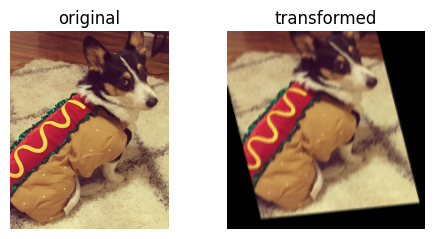

In [13]:
transforms = A.Compose(
    [
        A.Resize(height=SIZE, width=SIZE, p=1.0),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.MotionBlur(blur_limit=(3, 10), p=1),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"]) 

Albumentations также позволяет использовать несколько аугментаций из одной категории, случайным образом выбирая одну из них. Для этого используется конструкция `A.OneOf([])`, в которую передаются все необходимые из них. Для примера, зададим выбор в категории «перспектива и аффинные преобразования»:

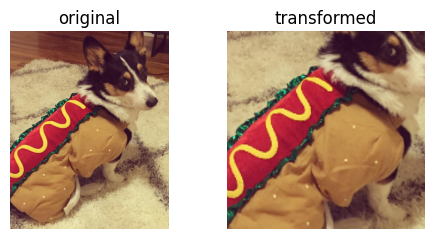

In [14]:
transforms = A.Compose([
    A.SmallestMaxSize(max_size=SIZE, p=1.0),
    A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
    A.OneOf([
        A.Affine(rotate=(-15, 15), shear=(-10, 10), p=0.8),
        A.Perspective(scale=(0.05, 0.1), p=0.8)
    ], p=0.7)
], seed=42)

plot_image(img, transforms(image=img)["image"]) 

# Задание 2
Используйте комбинацию аугментаций с произвольными параметрами: RandomResizedCrop, случайным выбором одной из аугментаций 
`СoarseDropout` или `GridDropout` на изображении img.
* Визуализируйте его (код уже написан).
* Установите вероятность всех аугментаций равной 1, seed=42.
* Целевой масштаб указан в параметре SIZE. 
* Примените нормализацию на каждом изображении в отдельности.
* Порядок применения: RandomResizedCrop, OneOf[CoarseDropout,GridDropout], Normalize.
* Используйте normalization="image".

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2826234..2.1711073].


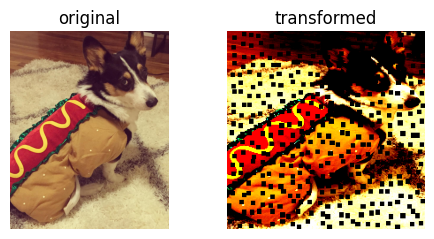

In [15]:
transforms = A.Compose([
    A.RandomResizedCrop(
        size=(SIZE, SIZE), scale=(0.8, 1.0), ratio=(0.75, 1.33), p=1.0),
    A.OneOf([
        A.CoarseDropout(num_holes_range=(1, 8),
                        hole_height_range=(int(0.1 * SIZE), int(0.2 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.2 * SIZE)),
                        p=1.0),
        A.GridDropout(ratio=0.5,
                      unit_size_range=(int(0.05 * SIZE), int(0.1 * SIZE)),
                      p=1),
    ], p=1),
    A.Normalize(normalization="image",
                p=1.0),
], seed=42)

plot_image(img, transforms(image=img)["image"]) 

Применяя аугментации, стоит отталкиваться от таких принципов:
* Начинайте с малого количества, а затем добавляйте новые, валидируя качество.
* Учитывайте специфику конкретного датасета — не все аугментации уместны всегда.